In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "README.md").is_file() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").is_file():
    raise FileNotFoundError("Run this notebook from the project directory or one of its subdirectories.")


# EXP08 — GBDT (LightGBM + XGBoost + CatBoost) Optimal Blending & Stacking

EXP05 (LightGBM), EXP06 (XGBoost), EXP07 (CatBoost)의 OOF 예측치 및 테스트 예측값을 불러와 대회 공식 평가지표($h_s \ge 1.5\text{m}$ 고파랑 6개 리드타임 통합 RMSE)를 직접 최소화하는 최적 가중치 앙상블을 수행합니다.

### 파이프라인 구성
1. **OOF 파일 로드**: `oof_exp05.csv`, `oof_exp06.csv`, `oof_exp07.csv`
2. **개별 모델 OOF 단독 성능 검증**: 각 모델별 리드타임/통합 고파랑 RMSE 확인
3. **리드타임별 최적 가중치 탐색 (SLSQP Constrained Optimization)**: $w_{\text{lgb}} + w_{\text{xgb}} + w_{\text{cat}} = 1.0$
4. **통합 앙상블 OOF 성능 평가 및 저장**: `oof_exp08.csv` 생성
5. **테스트셋 가중 앙상블 적용 및 제출 파일 생성**: `submission_exp08.csv` 생성

In [1]:
# ============================================================
# 0. SETUP & PACKAGES
# ============================================================
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print("Setup Complete for EXP08 Blending Ensemble.")

Setup Complete for EXP08 Blending Ensemble.


In [2]:
# ============================================================
# 1. CONFIG & FILE PATHS
# ============================================================
DATA_PATH = Path(PROJECT_ROOT / "data" / "processed" / "train_final_physics_v3.csv")
TEST_INDEX_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_index.csv")

# OOF 파일 경로 (현재 디렉토리 기준)
OOF_EXP05_PATH = Path(PROJECT_ROOT / "oof" / "oof_exp05.csv")
OOF_EXP06_PATH = Path(PROJECT_ROOT / "oof" / "oof_exp06.csv")
OOF_EXP07_PATH = Path(PROJECT_ROOT / "oof" / "oof_exp07.csv")

# Submission 파일 경로
SUB_EXP05_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp05.csv")
SUB_EXP06_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp06.csv")
SUB_EXP07_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp07.csv")

OOF_OUTPUT_PATH = Path(PROJECT_ROOT / "oof" / "oof_exp08.csv")
SUBMISSION_OUTPUT_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp08.csv")

LEAD_HOURS = [3, 6, 9, 12, 18, 24]
STEPS_PER_HOUR = 6
STEP_MINUTES = 10
INPUT_LEN = 289
LEAD_STEPS = [h * STEPS_PER_HOUR for h in LEAD_HOURS]

print("Target Leads:", LEAD_HOURS)

Target Leads: [3, 6, 9, 12, 18, 24]


In [ ]:
# ============================================================
# 2. LOAD OOF PREDICTIONS & GROUND TRUTH
# ============================================================
oof_lgb = pd.read_csv(OOF_EXP05_PATH)
oof_xgb = pd.read_csv(OOF_EXP06_PATH)
oof_cat = pd.read_csv(OOF_EXP07_PATH)

# 원본 Ground Truth (Y_true) 재생성/검증
df = pd.read_csv(DATA_PATH, parse_dates=["time"])
df = df.sort_values(["station", "time"]).reset_index(drop=True)
if "hs_original_observed" not in df.columns:
    df["hs_original_observed"] = df["hs"].notna().astype(np.int8)

y_rows, origin_hs_list = [], []
max_lead = max(LEAD_STEPS)
STRIDE = 1

for st, g in df.groupby("station"):
    g = g.sort_values("time").reset_index(drop=True)
    dt = pd.Series(g["time"]).diff().dt.total_seconds().div(60).to_numpy()

    for end_idx in range(INPUT_LEN - 1, len(g) - max_lead, STRIDE):
        start_idx = end_idx - INPUT_LEN + 1
        if not np.all(dt[start_idx + 1:end_idx + 1] == STEP_MINUTES):
            continue

        target_idx = [end_idx + s for s in LEAD_STEPS]
        y = g.loc[target_idx, "hs"].to_numpy(dtype=np.float32)
        obs = g.loc[target_idx, "hs_original_observed"].to_numpy(dtype=np.int8)
        if not np.isfinite(y).all() or not np.all(obs == 1):
            continue

        y_rows.append(y)
        origin_hs_list.append(float(g.loc[end_idx, "hs"]))

Y_true_arr = np.asarray(y_rows, dtype=np.float32)
origin_hs_arr = np.asarray(origin_hs_list, dtype=np.float32)
high_mask = origin_hs_arr >= 1.5

print(f"Loaded OOF Samples: {len(oof_lgb)} rows")
print(f"High-Wave Target Samples (hs >= 1.5m): {high_mask.sum()} / {len(origin_hs_arr)}")

Loaded OOF Samples: 43200 rows
High-Wave Target Samples (hs >= 1.5m): 10396 / 43200


In [4]:
# ============================================================
# 3. EVALUATE SINGLE MODEL PERFORMANCE (BASELINE)
# ============================================================
def calc_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def eval_model_oof(name, oof_df):
    preds = oof_df[[f"pred_{h}h" for h in LEAD_HOURS]].to_numpy()
    high_true = Y_true_arr[high_mask]
    high_pred = preds[high_mask]
    
    comp_rmse = calc_rmse(high_true, high_pred)
    overall_rmse = calc_rmse(Y_true_arr, preds)
    
    scores = {"Model": name, "Comp_Integrated_RMSE": comp_rmse, "Overall_RMSE": overall_rmse}
    for idx, h in enumerate(LEAD_HOURS):
        scores[f"Comp_{h}h"] = calc_rmse(high_true[:, idx], high_pred[:, idx])
    return scores

results = [
    eval_model_oof("EXP05 (LightGBM)", oof_lgb),
    eval_model_oof("EXP06 (XGBoost)", oof_xgb),
    eval_model_oof("EXP07 (CatBoost)", oof_cat)
]

print("\n===== SINGLE MODEL BASELINE OOF METRICS =====")
display(pd.DataFrame(results))


===== SINGLE MODEL BASELINE OOF METRICS =====


,Model,Comp_Integrated_RMSE,Overall_RMSE,Comp_3h,Comp_6h,Comp_9h,Comp_12h,Comp_18h,Comp_24h
0,EXP05 (LightGBM),0.240628,0.187852,0.243416,0.244565,0.240138,0.247374,0.231515,0.236405
1,EXP06 (XGBoost),0.240795,0.186909,0.240583,0.241678,0.242172,0.246497,0.234266,0.239411
2,EXP07 (CatBoost),0.278852,0.281843,0.278654,0.278368,0.280989,0.278632,0.274263,0.282143


In [5]:
# ============================================================
# 4. HORIZON-WISE OPTIMAL WEIGHT SEARCH (SLSQP)
# ============================================================
optimal_weights = {}
blend_oof_preds = np.zeros_like(Y_true_arr)

print("\nStarting Horizon-wise Constrained Optimization (hs >= 1.5m)...\n")

for idx, h in enumerate(LEAD_HOURS):
    col = f"pred_{h}h"
    p_lgb = oof_lgb[col].to_numpy()
    p_xgb = oof_xgb[col].to_numpy()
    p_cat = oof_cat[col].to_numpy()
    
    y_true_lead = Y_true_arr[:, idx]
    
    # 목적함수: 고파랑 샘플(hs >= 1.5m) 구간 RMSE 최소화
    def objective_func(weights):
        w1, w2, w3 = weights
        pred = w1 * p_lgb + w2 * p_xgb + w3 * p_cat
        return calc_rmse(y_true_lead[high_mask], pred[high_mask])
    
    init_weights = [1/3, 1/3, 1/3]
    bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]
    constraints = ({'type': 'eq', 'fun': lambda w: sum(w) - 1.0})
    
    res = minimize(objective_func, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    w1, w2, w3 = res.x
    optimal_weights[h] = (w1, w2, w3)
    
    blend_oof_preds[:, idx] = w1 * p_lgb + w2 * p_xgb + w3 * p_cat
    print(f"Lead +{h:02d}h -> LGB: {w1:.4f}, XGB: {w2:.4f}, CAT: {w3:.4f} | Lead High-RMSE: {res.fun:.5f}")

# 전체 6개 리드타임 공식 통합 RMSE 계산
y_true_high_all = Y_true_arr[high_mask]
y_pred_high_all = blend_oof_preds[high_mask]
final_comp_rmse = calc_rmse(y_true_high_all, y_pred_high_all)
final_overall_rmse = calc_rmse(Y_true_arr, blend_oof_preds)

print("\n" + "=" * 75)
print(f"★ EXP08 BLENDING ENSEMBLE INTEGRATED COMP RMSE: {final_comp_rmse:.5f} m")
print(f"★ EXP08 BLENDING ENSEMBLE OVERALL RMSE:         {final_overall_rmse:.5f} m")
print("=" * 75)


Starting Horizon-wise Constrained Optimization (hs >= 1.5m)...

Lead +03h -> LGB: 0.4131, XGB: 0.5869, CAT: 0.0000 | Lead High-RMSE: 0.23777
Lead +06h -> LGB: 0.4552, XGB: 0.5448, CAT: 0.0000 | Lead High-RMSE: 0.23781
Lead +09h -> LGB: 0.5408, XGB: 0.4592, CAT: 0.0000 | Lead High-RMSE: 0.23481
Lead +12h -> LGB: 0.4255, XGB: 0.4973, CAT: 0.0772 | Lead High-RMSE: 0.23974
Lead +18h -> LGB: 0.5395, XGB: 0.4496, CAT: 0.0109 | Lead High-RMSE: 0.22514
Lead +24h -> LGB: 0.5517, XGB: 0.4483, CAT: 0.0000 | Lead High-RMSE: 0.23044

★ EXP08 BLENDING ENSEMBLE INTEGRATED COMP RMSE: 0.23434 m
★ EXP08 BLENDING ENSEMBLE OVERALL RMSE:         0.18342 m


In [6]:
# ============================================================
# 5. SAVE BLENDED OOF PREDICTIONS
# ============================================================
oof_exp08_df = pd.DataFrame(blend_oof_preds, columns=[f"pred_{h}h" for h in LEAD_HOURS])
oof_exp08_df["origin_hs"] = origin_hs_arr
oof_exp08_df["origin_time"] = oof_lgb["origin_time"]

oof_exp08_df.to_csv(OOF_OUTPUT_PATH, index=False)
print(f"Saved Blended OOF: {OOF_OUTPUT_PATH}")

Saved Blended OOF: oof_exp08.csv


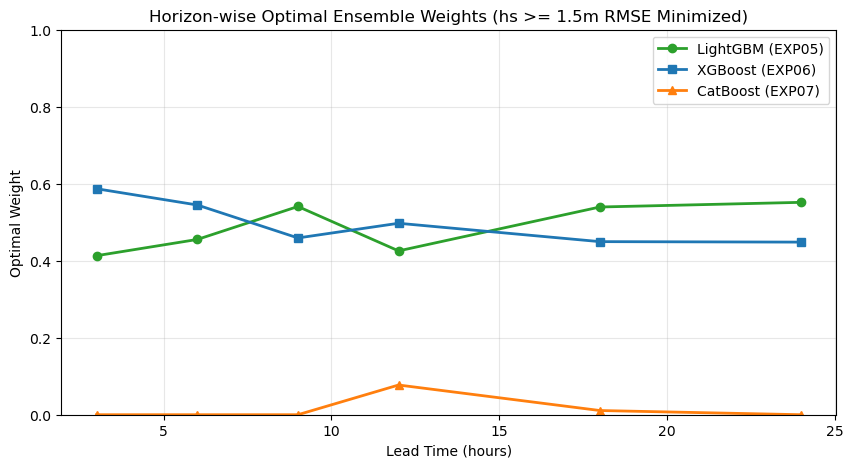

In [7]:
# ============================================================
# 6. PLOT ENSEMBLE WEIGHTS ACROSS LEAD TIMES
# ============================================================
weights_df = pd.DataFrame(optimal_weights, index=["LightGBM", "XGBoost", "CatBoost"]).T

plt.figure(figsize=(10, 5))
plt.plot(weights_df.index, weights_df["LightGBM"], marker='o', label="LightGBM (EXP05)", color="#2ca02c", linewidth=2)
plt.plot(weights_df.index, weights_df["XGBoost"], marker='s', label="XGBoost (EXP06)", color="#1f77b4", linewidth=2)
plt.plot(weights_df.index, weights_df["CatBoost"], marker='^', label="CatBoost (EXP07)", color="#ff7f0e", linewidth=2)

plt.xlabel("Lead Time (hours)")
plt.ylabel("Optimal Weight")
plt.title("Horizon-wise Optimal Ensemble Weights (hs >= 1.5m RMSE Minimized)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [8]:
# ============================================================
# 7. APPLY BLENDING TO TEST SUBMISSIONS & CREATE EXP08 CSV
# ============================================================
print("Applying Optimal Weights to Test Predictions...")

sub_lgb = pd.read_csv(SUB_EXP05_PATH)
sub_xgb = pd.read_csv(SUB_EXP06_PATH)
sub_cat = pd.read_csv(SUB_EXP07_PATH)

sub_final = sub_lgb.copy()
sub_final["hs_pred"] = 0.0

for h in LEAD_HOURS:
    w1, w2, w3 = optimal_weights[h]
    mask = sub_final["lead_h"] == h
    
    sub_final.loc[mask, "hs_pred"] = (
        w1 * sub_lgb.loc[mask, "hs_pred"] +
        w2 * sub_xgb.loc[mask, "hs_pred"] +
        w3 * sub_cat.loc[mask, "hs_pred"]
    )

# 물리적 상/하한 클리핑
sub_final["hs_pred"] = sub_final["hs_pred"].clip(lower=0.0, upper=30.0)
sub_final.to_csv(SUBMISSION_OUTPUT_PATH, index=False, encoding="utf-8")

print("=" * 80)
print(f"EXP08 FINAL BLENDED SUBMISSION SAVED: {SUBMISSION_OUTPUT_PATH}")
print("=" * 80)
print("\nPrediction Statistics:")
display(sub_final["hs_pred"].describe())
display(sub_final.head(12))

Applying Optimal Weights to Test Predictions...
EXP08 FINAL BLENDED SUBMISSION SAVED: submission_exp08.csv

Prediction Statistics:


count    1200.000000
mean        1.602725
std         0.470738
min         0.395033
25%         1.287377
50%         1.571345
75%         1.854423
max         4.044161
Name: hs_pred, dtype: float64

,case_id,station,lead_h,hs_pred
0,C0001,S-ORS,3,2.546176
1,C0001,S-ORS,6,1.465129
2,C0001,S-ORS,9,1.287127
3,C0001,S-ORS,12,1.666340
4,C0001,S-ORS,18,0.911225
5,C0001,S-ORS,24,1.099857
6,C0002,I-ORS,3,1.576778
7,C0002,I-ORS,6,1.573365
8,C0002,I-ORS,9,1.606283
9,C0002,I-ORS,12,1.614459
